# Writing Your Own Element

An element supplies only its geometry. `Element` derives everything else from it:
the Jacobian, the strain matrix, the constitutive relationship, the stiffness and
the tangent. The contract is four things:

| | |
|---|---|
| `NumNodes` | nodes on the element |
| `QuadOrder` | Gauss points per direction |
| `ShapeFunctions(xi, eta)` | `(NumNodes,)` values |
| `ShapeDerivatives(xi, eta)` | `(2, NumNodes)`, rows d/dxi and d/deta |

The element built below is deliberately awkward: it interpolates with $\sin^2$ and
$\cos^2$ instead of polynomials, so Gauss quadrature can never integrate it exactly.

In [1]:
import contextlib
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np

from fem2d.elements import (Element, Q4, RegisterElement, RegisteredElements,
                            ShapeDerivative)
from fem2d.meshers import Mesh
from fem2d.solvers import LinearSolver, NonLinearSolver

logging.basicConfig(level=logging.INFO, format='%(message)s', stream=sys.stdout)
SolverLog = logging.getLogger('fem2d.solvers')


@contextlib.contextmanager
def quiet():
    # Silence the solver progress log.
    SolverLog.setLevel(logging.WARNING)
    try:
        yield
    finally:
        SolverLog.setLevel(logging.NOTSET)


E, v, t, plane = 210000.0, 0.3, 1.0, 1

## The interpolation

Two blending functions on $\xi \in [-1, 1]$:

$$a(\xi) = \cos^2\!\Big(\tfrac{\pi(1+\xi)}{4}\Big) = \tfrac{1}{2}\Big(1 - \sin\tfrac{\pi\xi}{2}\Big),
\qquad
b(\xi) = \sin^2\!\Big(\tfrac{\pi(1+\xi)}{4}\Big) = \tfrac{1}{2}\Big(1 + \sin\tfrac{\pi\xi}{2}\Big)$$

$a$ is 1 at $\xi = -1$ and 0 at $\xi = +1$, $b$ the other way round, and
$a + b = 1$ identically. Taking the tensor product over the four corners gives shape
functions that sum to one everywhere and are 1 at their own node, 0 at the others.

Differentiating, $a'(\xi) = -\tfrac{\pi}{4}\cos\tfrac{\pi\xi}{2}$ and
$b'(\xi) = +\tfrac{\pi}{4}\cos\tfrac{\pi\xi}{2}$.

In [2]:
class TrigQuad(Element):
    '''Four node quadrilateral interpolated with sin^2 and cos^2.'''

    NumNodes = 4
    QuadOrder = 2

    @staticmethod
    def _Blend(u):
        # a is 1 at u = -1 and 0 at u = +1; b is the mirror; a + b = 1.
        return np.cos(np.pi*(1 + u)/4)**2, np.sin(np.pi*(1 + u)/4)**2

    @staticmethod
    def _dBlend(u):
        return -np.pi/4*np.cos(np.pi*u/2), np.pi/4*np.cos(np.pi*u/2)

    def ShapeFunctions(self, xi, eta):
        a_xi, b_xi = self._Blend(xi)
        a_et, b_et = self._Blend(eta)

        return np.array([a_xi*a_et, b_xi*a_et, b_xi*b_et, a_xi*b_et])

    def ShapeDerivatives(self, xi, eta):
        a_xi, b_xi = self._Blend(xi)
        a_et, b_et = self._Blend(eta)
        da_xi, db_xi = self._dBlend(xi)
        da_et, db_et = self._dBlend(eta)

        return np.array([[da_xi*a_et, db_xi*a_et, db_xi*b_et, da_xi*b_et],
                         [a_xi*da_et, b_xi*da_et, b_xi*db_et, a_xi*db_et]])


class dTrigQuaddX(ShapeDerivative, TrigQuad):
    '''Shape derivatives. Nothing to write: the mixin is generic.'''


RegisterElement('Trig', TrigQuad, dTrigQuaddX)
print('registered elements:', RegisteredElements())

registered elements: ['5B', 'Q4', 'Q8', 'Trig']


That is the whole element. Everything else is inherited.

## Does it satisfy the basics?

Shape functions must sum to one (rigid body translation) and be 1 at their own node
(so nodal values are the degrees of freedom). The derivatives should match a finite
difference of the shape functions.

In [3]:
NodeCoor = np.array([[0.0, 0.0], [2.0, 0.0], [2.0, 1.0], [0.0, 1.0]])
El = TrigQuad(NodeCoor, t, E, v, plane)

print('partition of unity and nodal values')
for xi, eta in [(-1, -1), (1, -1), (1, 1), (-1, 1), (0.3, -0.7)]:
    N = El.ShapeFunctions(xi, eta)
    print(f'   ({xi:+.1f},{eta:+.1f})  sum = {N.sum():.15f}   N = {np.round(N, 4)}')

h = 1e-6
Worst = 0.0
for xi, eta in [(0.3, -0.7), (-0.5, 0.2), (0.0, 0.0)]:
    FD = np.array([(El.ShapeFunctions(xi + h, eta) - El.ShapeFunctions(xi - h, eta))/(2*h),
                   (El.ShapeFunctions(xi, eta + h) - El.ShapeFunctions(xi, eta - h))/(2*h)])
    Worst = max(Worst, np.abs(FD - El.ShapeDerivatives(xi, eta)).max())

print(f'\nderivatives vs central difference: max error {Worst:.2e}')

partition of unity and nodal values
   (-1.0,-1.0)  sum = 1.000000000000000   N = [1. 0. 0. 0.]
   (+1.0,-1.0)  sum = 1.000000000000000   N = [0. 1. 0. 0.]
   (+1.0,+1.0)  sum = 1.000000000000000   N = [0. 0. 1. 0.]
   (-1.0,+1.0)  sum = 1.000000000000000   N = [0. 0. 0. 1.]
   (+0.3,-0.7)  sum = 1.000000000000000   N = [0.2581 0.6874 0.0396 0.0149]

derivatives vs central difference: max error 1.44e-10


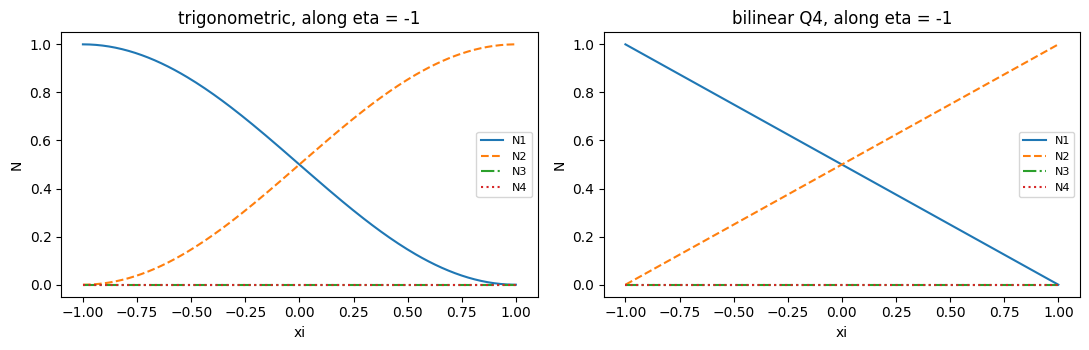

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))

Xi = np.linspace(-1, 1, 200)
Ref = Q4(NodeCoor, t, E, v, plane)
for i, style in enumerate(('-', '--', '-.', ':')):
    a1.plot(Xi, [El.ShapeFunctions(x, -1.0)[i] for x in Xi], style, label=f'N{i+1}')
a1.set(xlabel='xi', ylabel='N', title='trigonometric, along eta = -1')
a1.legend(fontsize=8)

for i, style in enumerate(('-', '--', '-.', ':')):
    a2.plot(Xi, [Ref.ShapeFunctions(x, -1.0)[i] for x in Xi], style, label=f'N{i+1}')
a2.set(xlabel='xi', ylabel='N', title='bilinear Q4, along eta = -1')
a2.legend(fontsize=8)
plt.tight_layout()

## It solves

Register it and the solvers pick it up like any built in element.

In [5]:
def Cantilever(ElementType, el_num=8):
    m = Mesh(E, v, t, plane, ElementType)
    m.SimpleBeam(el_num, 10.0, 0.5, -25.0)
    return m


m = Cantilever('Trig')
with quiet():
    LinearSolver(m).Solve()

print(f"tip deflection = {m.U[-1, 0]:.6f}")

tip deflection = -0.587077


## Is it a legitimate element?

Two classical checks. Three zero eigenvalues means it has exactly the rigid body
modes and no spurious mechanisms. The patch test asks whether a linear displacement
field is reproduced exactly; if the strain varies across the element, the element
cannot converge.

In [6]:
print(f"{'element':<8}{'zero eigenvalues':>18}{'strain variation under a linear field':>40}")
for Name, Cls in (('Q4', Q4), ('Trig', TrigQuad)):
    e = Cls(NodeCoor, t, E, v, plane)

    Eigen = np.sort(np.abs(np.linalg.eigvalsh(e.StiffMatrix(GaussPoints=12))))
    Zero = int((Eigen < 1e-6*Eigen.max()).sum())

    # u = 1e-4 (2 + 3x - y),  w = 1e-4 (-1 + x + 4y)   ->  exx = 3e-4, eyy = 4e-4, gxy = 0
    U = np.zeros((8, 1))
    for i, (x, y) in enumerate(NodeCoor):
        U[2*i, 0] = 1e-4*(2 + 3*x - y)
        U[2*i + 1, 0] = 1e-4*(-1 + x + 4*y)

    Strains = np.array([e.B(xi, eta) @ U for xi, eta in [(-0.5, -0.5), (0.2, 0.6), (0.0, 0.0)]])
    print(f"{Name:<8}{Zero:>18}{np.abs(Strains - Strains[0]).max():>40.2e}")

print(f"\nstrain at the centre, trig element: {np.round(Strains[2].ravel(), 8)}")
print('exact:                              [0.0003   0.0004   0.      ]')

element   zero eigenvalues   strain variation under a linear field
Q4                       3                                1.08e-19
Trig                     3                                5.42e-20

strain at the centre, trig element: [0.0003 0.0004 0.    ]
exact:                              [0.0003   0.0004   0.      ]


Both pass. The trigonometric element is not a broken element.

## In fact it *is* Q4

Write $s = \sin\tfrac{\pi\xi}{2}$. Then $a(\xi) = \tfrac{1}{2}(1-s)$, which is the
bilinear blend in $s$. Geometry and displacement both use these functions, so the
substitution cancels: the physical element is identical, only its local coordinate is
stretched. Any difference you measure is therefore pure quadrature error.

In [7]:
Cases = {
    'square':        np.array([[0.0, 0.0], [1, 0], [1, 1], [0, 1]]),
    'parallelogram': np.array([[0.0, 0.0], [2, 0], [2.6, 1], [0.6, 1]]),
    'trapezoid':     np.array([[0.0, 0.0], [2, 0], [1.6, 1], [0.4, 1]]),
    'curved':        np.array([[1.0, 0.0], [2, 0], [1.4, 1.4], [0.7, 0.7]]),
}

print('the same shape functions, reparameterised')
for xi, eta in [(0.5, -0.3), (-0.7, 0.9)]:
    s, r = np.sin(np.pi*xi/2), np.sin(np.pi*eta/2)
    print(f'   trig({xi:+.1f},{eta:+.1f}) = {np.round(El.ShapeFunctions(xi, eta), 6)}')
    print(f'   Q4  ({s:+.3f},{r:+.3f}) = {np.round(Ref.ShapeFunctions(s, r), 6)}')

print(f"\n{'geometry':<15}{'||K_trig - K_Q4|| / ||K_Q4||, both at 40 points':>48}")
for Name, nc in Cases.items():
    Kq = Q4(nc, t, E, v, plane).StiffMatrix(GaussPoints=40)
    Kt = TrigQuad(nc, t, E, v, plane).StiffMatrix(GaussPoints=40)
    print(f'{Name:<15}{np.linalg.norm(Kt - Kq)/np.linalg.norm(Kq):>48.2e}')

the same shape functions, reparameterised
   trig(+0.5,-0.3) = [0.106466 0.620529 0.233024 0.039981]
   Q4  (+0.707,-0.454) = [0.106466 0.620529 0.233024 0.039981]
   trig(-0.7,+0.9) = [5.82000e-03 3.35000e-04 5.41610e-02 9.39683e-01]
   Q4  (-0.891,+0.988) = [5.82000e-03 3.35000e-04 5.41610e-02 9.39683e-01]

geometry        ||K_trig - K_Q4|| / ||K_Q4||, both at 40 points


square                                                 7.63e-15


parallelogram                                          9.61e-15


trapezoid                                              9.37e-15


curved                                                 8.68e-15


## The catch: Gauss cannot integrate it

An $n$ point Gauss rule integrates polynomials up to degree $2n-1$ exactly. The Q4
integrand is polynomial on a parallelogram, so $2 \times 2$ is exact and adding points
changes nothing. The trigonometric integrand is transcendental, so no rule is ever
exact; it only converges.

 points            Q4          Trig
      2      2.00e-15      2.64e-01
      3      1.89e-15      6.96e-02
      4      2.10e-15      8.14e-03
      5      1.91e-15      5.58e-04
      6      2.10e-15      2.53e-05
      8      1.65e-15      1.97e-08
     10      2.10e-15      5.56e-12
     12      1.84e-15      6.90e-15
     14      2.28e-15      7.59e-15


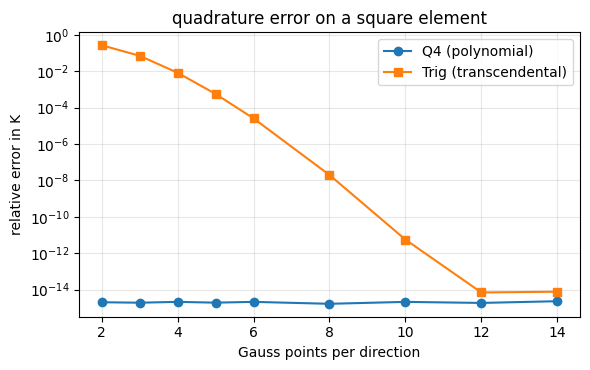

In [8]:
Ref40 = {n: c(Cases['square'], t, E, v, plane).StiffMatrix(GaussPoints=40)
         for n, c in (('Q4', Q4), ('Trig', TrigQuad))}

Orders = [2, 3, 4, 5, 6, 8, 10, 12, 14]
Err = {'Q4': [], 'Trig': []}
for n in Orders:
    for Name, Cls in (('Q4', Q4), ('Trig', TrigQuad)):
        K = Cls(Cases['square'], t, E, v, plane).StiffMatrix(GaussPoints=n)
        Err[Name].append(np.linalg.norm(K - Ref40[Name])/np.linalg.norm(Ref40[Name]))

print(f"{'points':>7}{'Q4':>14}{'Trig':>14}")
for i, n in enumerate(Orders):
    print(f"{n:>7}{Err['Q4'][i]:>14.2e}{Err['Trig'][i]:>14.2e}")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.semilogy(Orders, np.maximum(Err['Q4'], 1e-16), 'o-', label='Q4 (polynomial)')
ax.semilogy(Orders, np.maximum(Err['Trig'], 1e-16), 's-', label='Trig (transcendental)')
ax.set(xlabel='Gauss points per direction', ylabel='relative error in K',
       title='quadrature error on a square element')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

## What that costs in a real solve

`QuadOrder` is a class attribute, so a subclass fixes a different rule. At the
default $2 \times 2$ the tip deflection is badly wrong, and it takes about ten points
per direction before the answer settles.

In [9]:
def TrigWith(n):
    '''Register a copy of the element that integrates at n points per direction.'''

    Elem = type(f'TrigQuad{n}', (TrigQuad,), {'QuadOrder': n})
    Deriv = type(f'dTrigQuad{n}dX', (ShapeDerivative, Elem), {})
    RegisterElement(f'Trig{n}', Elem, Deriv)

    return f'Trig{n}'


with quiet():
    Exact = Cantilever(TrigWith(20))
    LinearSolver(Exact).Solve()
Settled = Exact.U[-1, 0]

print(f"{'points':>7}{'tip deflection':>18}{'error':>12}{'relative':>12}")
Tips = []
for n in Orders:
    with quiet():
        m = Cantilever(TrigWith(n))
        LinearSolver(m).Solve()
    Tips.append(m.U[-1, 0])
    Rel = abs(m.U[-1, 0]/Settled - 1)
    print(f"{n:>7}{m.U[-1, 0]:>18.6f}{Rel:>11.2%}{Rel:>12.1e}")

print(f"\nsettled value {Settled:.6f}")
print(f"the default 2x2 rule is off by {abs(Tips[0]/Settled - 1):.0%}")

 points    tip deflection       error    relative
      2         -0.587077     42.34%     4.2e-01
      3         -1.272513     24.98%     2.5e-01
      4         -0.994941      2.28%     2.3e-02
      5         -1.019794      0.16%     1.6e-03
      6         -1.018088      0.01%     7.3e-05


      8         -1.018161      0.00%     5.6e-08
     10         -1.018162      0.00%     9.5e-11


     12         -1.018162      0.00%     5.3e-11


     14         -1.018162      0.00%     1.3e-10

settled value -1.018162
the default 2x2 rule is off by 42%


### A quadrature point too far

One point per direction is a different failure. It under-integrates so badly that the
element loses rank, the assembled system becomes singular, and the answer is nonsense
rather than merely inaccurate. This is the hourglass mechanism, and it catches the
polynomial Q4 too.

In [10]:
with quiet():
    for Name in ('Q4', 'Trig'):
        Under = type(f'{Name}1', (Q4 if Name == 'Q4' else TrigQuad,), {'QuadOrder': 1})
        RegisterElement(f'{Name}OnePoint', Under, type(f'd{Name}1', (ShapeDerivative, Under), {}))
        m = Cantilever(f'{Name}OnePoint')
        LinearSolver(m).Solve()
        print(f'{Name:<6} one point per direction: tip = {m.U[-1, 0]:.4g}')

Q4     one point per direction: tip = -1.817e+12
Trig   one point per direction: tip = -5.007e+11


## Two things worth noticing

**The Jacobian degenerates at the corners.** The geometry map is
$x = h\sin\tfrac{\pi\xi}{2}$, whose derivative vanishes at $\xi = \pm 1$. Gauss points
are interior so nothing breaks, but the element is singular at its own corners.

**Q4 is not exactly integrated either, once distorted.** On a non parallelogram the
Jacobian varies, the integrand becomes rational rather than polynomial, and $2 \times 2$
stops being exact. The trigonometric element makes that easy to see because it is the
same element.

   Q4 at 2x2, square         error 2.00e-15
   Q4 at 2x2, parallelogram  error 2.84e-15
   Q4 at 2x2, trapezoid      error 2.05e-03
   Q4 at 2x2, curved         error 5.78e-03


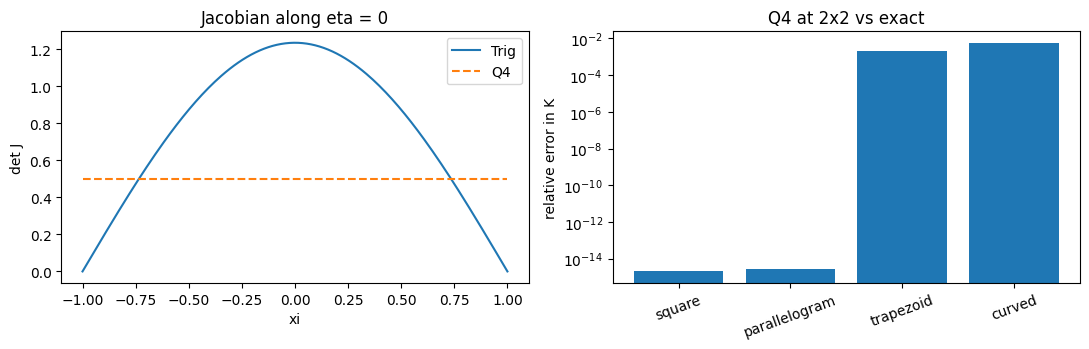

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))

Xi = np.linspace(-1, 1, 200)
a1.plot(Xi, [El.detJ(x, 0.0) for x in Xi], label='Trig')
a1.plot(Xi, [Ref.detJ(x, 0.0) for x in Xi], '--', label='Q4')
a1.set(xlabel='xi', ylabel='det J', title='Jacobian along eta = 0')
a1.legend()

Names = list(Cases)
Q4Err = []
for Name in Names:
    K2 = Q4(Cases[Name], t, E, v, plane).StiffMatrix(GaussPoints=2)
    K40 = Q4(Cases[Name], t, E, v, plane).StiffMatrix(GaussPoints=40)
    Q4Err.append(np.linalg.norm(K2 - K40)/np.linalg.norm(K40))

a2.bar(Names, np.maximum(Q4Err, 1e-16))
a2.set_yscale('log')
a2.set(ylabel='relative error in K', title='Q4 at 2x2 vs exact')
a2.tick_params(axis='x', rotation=20)
plt.tight_layout()

for Name, e in zip(Names, Q4Err, strict=True):
    print(f'   Q4 at 2x2, {Name:<14} error {e:.2e}')

## Sensitivities come for free

`ShapeDerivative` is written against the `Element` interface, so the shape
sensitivities work for a new element with no extra code. Checked against a central
difference of the whole solve.

In [12]:
ElementType = TrigWith(12)

with quiet():
    m = Cantilever(ElementType)
    LinearSolver(m, Sensitivity=True).Solve()

print(f"{'variable':<10}{'analytic':>16}{'central FD':>16}{'rel err':>11}")
for var, (Name, dL, dH) in enumerate([('Length', 1e-3, 0.0), ('Height', 0.0, 5e-5)]):
    Ends = []
    for Sign in (+1, -1):
        with quiet():
            p = Mesh(E, v, t, plane, ElementType)
            p.SimpleBeam(8, 10.0 + Sign*dL, 0.5 + Sign*dH, -25.0)
            LinearSolver(p).Solve()
        Ends.append(p.U[-1, 0])

    FD = (Ends[0] - Ends[1])/(2*(dL or dH))
    An = m.dUdx[-1, var]
    print(f'{Name:<10}{An:>16.6e}{FD:>16.6e}{abs(An - FD)/abs(FD):>11.1e}')

variable          analytic      central FD    rel err


Length       -1.744528e-01   -1.744527e-01    3.1e-07


Height        3.489055e+00    3.489055e+00    3.0e-08


In [13]:
# And it runs through the nonlinear solver unchanged.
with quiet():
    m = Cantilever(TrigWith(10))
    NonLinearSolver(m, LoadSteps=2, MaxIter=20, tol=1e-8, Sensitivity=True).Solve()

print(f'nonlinear tip = {m.U[-1, 0]:.6f},  dUdx = {np.round(m.dUdx[-1], 5)}')

nonlinear tip = -1.015967,  dUdx = [-0.17229  3.41994]


## Summary

Adding an element took two methods and a `RegisterElement` call. Everything else,
including the shape sensitivities and all three solvers, followed from the `Element`
interface.

The element itself is a useful teaching case: it is mathematically identical to Q4,
passes the patch test and has the right rigid body modes, yet the default
$2 \times 2$ rule gets the tip deflection wrong by a wide margin, purely because the
integrand stopped being polynomial. Choosing a quadrature rule is part of designing an
element, not an afterthought.